# **Seminar 4 - Neural Networks**
**Part I: Data preparation & analysis**
Your job in this part of the seminar is to visualize and understand the data that you are
going to use to train and evaluate your neural network. Complete the following tasks:
1. Describe the statistics behind the main parameters of the dataset. For that, make use
of the plots that you consider.
2. Perform a correlation analysis between the main features in the dataset and the performance metrics (throughput and delay).

**Part II: FNN-based performance predictor**
Now, you will design and implement a feedforward neural network (FNN) that predicts
the performance of the Wi-Fi network (throughput and latency) based on the features you
consider. The implementation of a neural network involves multiple considerations, so we
ask you to complete the following tasks:
1. Feature selection: select the features that you think will be most appropriate to
predict Wi-Fi performance.
2. Data preparation: apply the necessary data transformation techniques for your data
(e.g., normalization, encoding).
3. FNN architecture design: design your FNN and try to justify your choices (number
of layers, input/output layers, activations, loss function, optimizer, regularization, etc.)
according to the problem and data at hand.
Note: You can design a multi-output FNN that predicts both the throughput and the
delay, or define two different FNNs (with the same architecture or not) to predict the
two metrics separately.
4. Train your FNN: use the training data to train your FNN. Describe your training
approach (epochs, batches, validation) and show the training process (e.g., validation
loss per epoch).
5. Evaluate your FNN: evaluate your solution using the test data and report the results.

## **Part I: Data preparation & analysis**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [9]:
test_data = pd.read_csv("dataset_Seminar4/test_data.csv")
train_data = pd.read_csv("dataset_Seminar4/train_data.csv")
test_data

,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,16,-53.19,787.51,653.48,1,15.94,56.30
1,24,-62.79,657.90,592.37,1,17.31,49.78
2,34,-71.16,259.18,178.29,0,2.89,55.83
3,28,-63.99,467.56,375.04,1,17.01,85.71
4,6,-69.29,355.26,313.15,1,14.05,59.40
...,...,...,...,...,...,...,...
8395,12,-67.32,344.98,210.24,1,14.80,50.99
8396,8,-66.35,335.82,364.28,1,14.35,52.11
8397,9,-62.54,511.97,477.08,1,14.93,68.64
8398,10,-60.21,473.17,349.06,1,17.31,48.74


#### 1. Describe the statistics behind the main parameters of the dataset. For that, make use of the plots that you consider.

In [15]:
statistics = pd.DataFrame({
    'Feature': train_data.columns,
    'Mean': train_data.mean().values,
    'Std Dev': train_data.std().values,
    'Min': train_data.min().values,
    'Max': train_data.max().values
})

print("=" * 100)
print("FEATURE STATISTICS")
print("=" * 100)
print(statistics.to_string(index=False))

FEATURE STATISTICS
       Feature       Mean    Std Dev    Min    Max
LocationNumber  18.151161  10.338002   1.00  36.00
          RSSI -62.364212   9.442463 -79.04 -37.02
   TxLinkSpeed 491.264874 240.868700  33.24 905.39
   RxLinkSpeed 460.954107 251.600115 -12.53 911.00
 MainAPConnect   0.913958   0.280430   0.00   1.00
  TxThroughput  12.988920   4.413973   0.78  19.16
AvgPingLatency  54.771372   8.735672  39.30  96.55


By analyzing the statistical metrics (Mean, Min, Max), three critical characteristics of the dataset were identified:

- Data anomaly (Outlier): The minimum value of RxLinkSpeed is negative (−12.53), which is physically does not make sense in networks and indicates a measurement error during data collection.

- Connection imbalance: The mean of MainAPConnect is 0.91, meaning that 91% of the data comes from clients connected to the main AP, leaving only 9% for the extender.

- Artificial limit: The maximum TxThroughput is topped at 19.11 Mbps despite link speeds reaching 900 Mbps. This can mean a limitation of the Internet line.

In [ ]:
# Get rid of outliers
train_data_clean = train_data[train_data['RxLinkSpeed'] >= 0]
test_data_clean = test_data[test_data['RxLinkSpeed'] >= 0]

statistics = pd.DataFrame({
    'Feature': train_data_clean.columns,
    'Mean': train_data_clean.mean().values,
    'Std Dev': train_data_clean.std().values,
    'Min': train_data_clean.min().values,
    'Max': train_data_clean.max().values
})

print("=" * 100)
print("FEATURE STATISTICS")
print("=" * 100)
print(statistics.to_string(index=False))

FEATURE STATISTICS
       Feature       Mean    Std Dev    Min    Max
LocationNumber  18.145643  10.334207   1.00  36.00
          RSSI -62.357904   9.440532 -79.04 -37.02
   TxLinkSpeed 491.419901 240.823717  33.24 905.39
   RxLinkSpeed 461.204304 251.435261   0.09 911.00
 MainAPConnect   0.913972   0.280410   0.00   1.00
  TxThroughput  12.990727   4.413895   0.78  19.16
AvgPingLatency  54.772346   8.737815  39.30  96.55


#### 2. Perform a correlation analysis between the main features in the dataset and the performance metrics (throughput and delay).

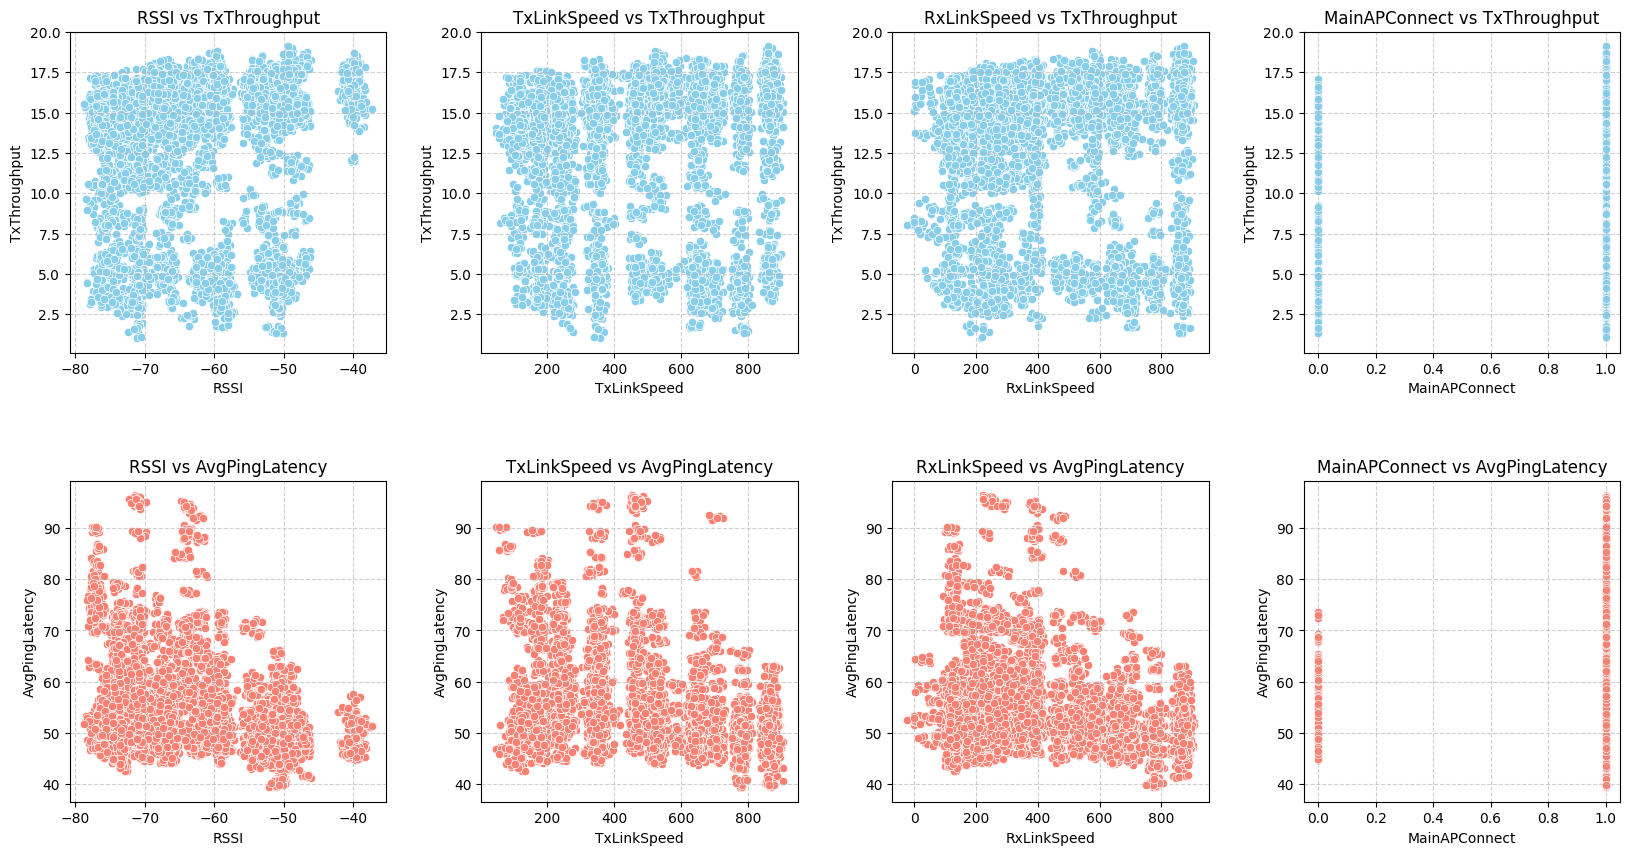

In [ ]:
features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']

# Define the target variables
targets = ['TxThroughput', 'AvgPingLatency']

fig, axes = plt.subplots(nrows=2, ncols=len(features), figsize=(20, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, target in enumerate(targets):
    for j, feature in enumerate(features):
        sns.scatterplot(data=test_data, x=feature, y=target, ax=axes[i, j], color='skyblue' if i==0 else 'salmon')
        axes[i, j].set_title(f"{feature} vs {target}")
        axes[i, j].grid(True, linestyle='--', alpha=0.6)

plt.show()

The scatter plots reveal the physical behavior of the system:

- Throughput: There is a non-linear positive correlation. Performance improves as signal strength (RSSI) and LinkSpeeds increase, but it suffers a complete saturation effect starting from medium values due to the 19 Mbps limit mentioned in Task 1.

- Latency: There is a negative and exponential correlation. Latency is low and stable (∼50 ms) under good conditions but spikes suddenly (up to >90 ms) if the signal becomes critical (RSSI<−65 dBm) or when the extender is used (MainAPConnect = 0) due to the additional wireless hop introduced by this device.

Basically, throughput and latency have an inverse correlation. The higher the throughput is, the lower the latency is, and viceversa. This is a typical behavior given that if the throughput is higher, more information is being transmitted or recieved, thus lowering the latency of the connections.

## **Part II: FNN-based performance predictor**

#### 1. Feature selection: select the features that you think will be most appropriate to predict Wi-Fi performance. ####
#### 2. Data preparation: apply the necessary data transformation techniques for your data (e.g., normalization, encoding). ####

`RSSI`, `TxLinkSpeed`, `RxLinkSpeed`, and `MainAPConnect` were selected as inputs (X), as they have a direct impact on performance according to the correlation analysis, whereas `LocationNumber` is discarded to prevent the network from interpreting it as an incremental continuous variable, which would harm the learning process.

Due to the disparity in the scales of the input variables (RSSI ranges in negative values from −40 to −80, and link speeds in positive values up to 900), a normalization transformation is applied using `StandardScaler` from `scikit-learn` for both features (X) and targets (y), ensuring stable network convergence.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature selection 
features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']
targets = ['TxThroughput', 'AvgPingLatency']

X_train = train_data_clean[features]
y_train = train_data_clean[targets]

X_test = test_data[features]
y_test = test_data[targets]

# Data preparation
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)


#### 3. FNN architecture design: design your FNN and try to justify your choices (number of layers, input/output layers, activations, loss function, optimizer, regularization, etc.) according to the problem and data at hand. Note: You can design a multi-output FNN that predicts both the throughput and the delay, or define two different FNNs (with the same architecture or not) to predict the two metrics separately. ####
#### 4. Train your FNN: use the training data to train your FNN. Describe your training approach (epochs, batches, validation) and show the training process (e.g., validation loss per epoch).

A multi-output regression model based on scikit-learn's MLPRegressor class is designed.

- Architecture: 4 input neurons, two hidden layers with 64 and 32 neurons respectively, and an output layer with 2 neurons (TxThroughput and AvgPingLatency).

- Justified parameters: ReLU activation function in the hidden layers and linear activation at the output. Adam is chosen as the optimization method due to its adaptive learning rate, and Mean Squared Error is used as the loss function.

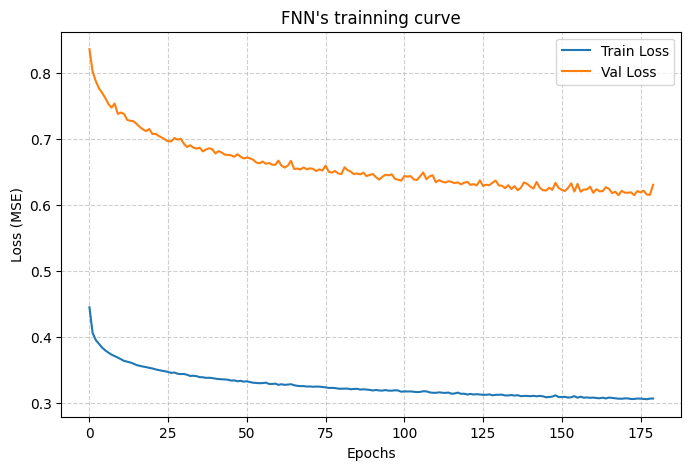

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Definition of the neural network 
fnn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    activation='relu',          
    solver='adam',              
    max_iter=500,                
    early_stopping=True,         
    validation_fraction=0.15,    # Reserve 15% of training data for validation
    random_state=42              
)

# Model training
fnn_model.fit(X_train_scaled, y_train_scaled)

# Training process
plt.figure(figsize=(8, 5))
plt.plot(fnn_model.loss_curve_, label='Train Loss')
if fnn_model.early_stopping:
    plt.plot(1 - np.array(fnn_model.validation_scores_), label='Val Loss')

plt.title("FNN's trainning curve")
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The model is trained by reserving 15% of the training data as a validation set to control overfitting. The obtained training curve shows a drop in loss within the first 50 epochs. The early stopping algorithm is correctly triggered around epoch 200 when it detects that the validation loss has reached a plateau, saving computation time and ensuring the model generalizes well without overitting.

#### 5. Evaluate your FNN: evaluate your solution using the test data and report the results ####

Metrics for: TxThroughput
 RMSE: 3.74
 R²:   0.2896
Metrics for: AvgPingLatency
 RMSE: 6.32
 R²:   0.4775


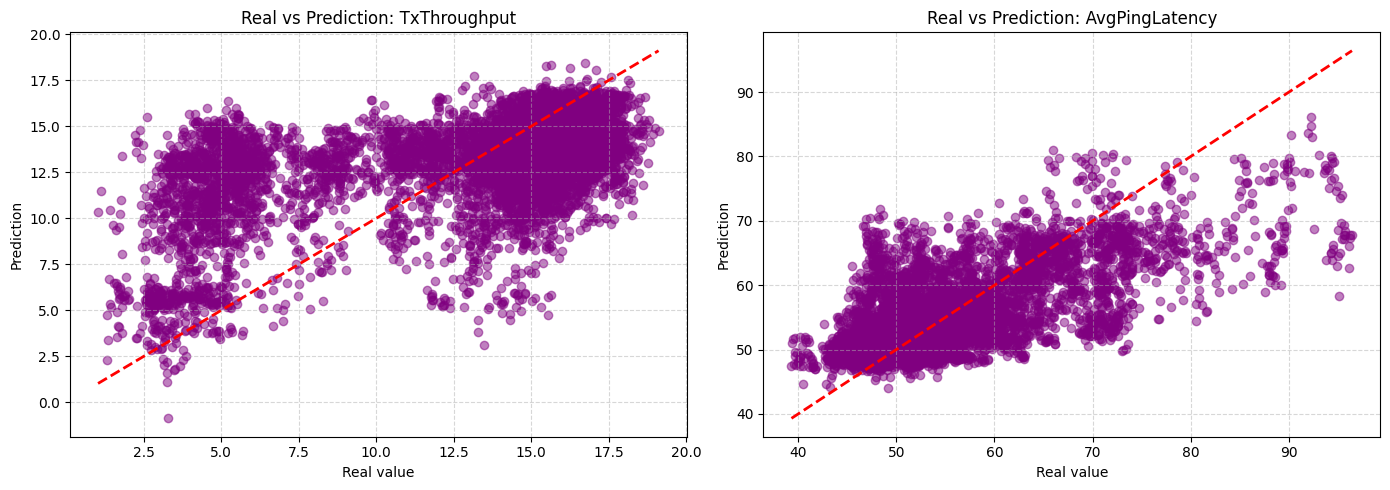

In [ ]:
# Make predictions on the test set 
y_pred_scaled = fnn_model.predict(X_test_scaled)

# Undo normalization to get real values
y_pred = scaler_y.inverse_transform(y_pred_scaled)


# Calculate metrics for each variable
for i, target in enumerate(targets):
    y_true_col = y_test[target]
    y_pred_col = y_pred[:, i]
    
    mse = mean_squared_error(y_true_col, y_pred_col)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_col, y_pred_col)
    
    print(f"Metrics for: {target}")
    print(f" RMSE: {rmse:.2f}")
    print(f" R²:   {r2:.4f}")

# Comparative plot Prediction vs Reality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(targets):
    axes[i].scatter(y_test[target], y_pred[:, i], alpha=0.5, color='purple')
    axes[i].plot([y_test[target].min(), y_test[target].max()], 
                 [y_test[target].min(), y_test[target].max()], 'r--', lw=2)
    axes[i].set_xlabel('Real value')
    axes[i].set_ylabel('Prediction')
    axes[i].set_title(f'Real vs Prediction: {target}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Testing on the test set gives two takeaways:

- TxThroughput (RMSE=3.74 Mbps, R²=0.29): The low R² is a ceiling effect, the ISP limits real throughput at 19 Mbps, which breaks the expected relationship. The model gets confused in good signal areas because a 400 Mbps and a 900 Mbps physical link speed both produce the exact same actual download speed.

- AvgPingLatency (RMSE=6.32 ms, R²=0.48): Decent results. The model captures around 48% of the variance, the rest comes from internet noise outside the Wi-Fi layer (server congestion, home network traffic, etc.) that the dataset simply can't see.
